# 📊 FX-AlphaLab — Data Understanding Visualizations

This notebook consolidates all visualizations from the Data Understanding phase.
All charts load from pre-computed CSVs — no live database connections required.

**Sections:**
1. MT5 Price Data
2. FRED Economic Indicators
3. Feature Engineering Overview
4. Integrated Data & Correlations
5. Data Quality Summary

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Paths
ROOT = Path('..').resolve()
OUTPUTS  = ROOT / 'data_understanding_outputs'
EDA_DIR  = OUTPUTS / 'eda'
FEAT_DIR = OUTPUTS / 'features'
INT_DIR  = OUTPUTS / 'integrated'
STAT_DIR = OUTPUTS / 'statistics'
PLOT_DIR = OUTPUTS / 'plots'

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

PAIRS = ['EURUSD', 'USDJPY', 'GBPUSD', 'USDCHF']
TIMEFRAMES = ['1H', '4H', '1D']

print('✅ Ready — loading from:', OUTPUTS)

✅ Ready — loading from: C:\Users\msi\forex-alpha-data\data_understanding_outputs


---
## 1. MT5 Price Data

In [2]:
# MT5 EDA Summary
mt5_summary = pd.read_csv(EDA_DIR / 'eda_summary_mt5.csv')
display(mt5_summary)

,Symbol,Timeframe,Candles,Date_Range,Avg_Price,Std_Return,Quality
0,EURUSD,1H,6222,2025-02-10 to 2026-02-10,1.145117,0.096934,OK
1,EURUSD,4H,1558,2025-02-10 to 2026-02-10,1.145159,0.191342,ISSUES
2,EURUSD,1D,260,2025-02-10 to 2026-02-10,1.145238,0.496328,ISSUES
3,USDJPY,1H,6222,2025-02-10 to 2026-02-10,149.695776,0.119201,OK
4,USDJPY,4H,1558,2025-02-10 to 2026-02-10,149.686756,0.239718,ISSUES
5,USDJPY,1D,260,2025-02-10 to 2026-02-10,149.697119,0.631049,ISSUES
6,GBPUSD,1H,6222,2025-02-10 to 2026-02-10,1.331238,0.089279,OK
7,GBPUSD,4H,1558,2025-02-10 to 2026-02-10,1.331292,0.176954,OK
8,GBPUSD,1D,260,2025-02-10 to 2026-02-10,1.331355,0.449485,OK
9,USDCHF,1H,6222,2025-02-10 to 2026-02-10,0.817588,0.110958,OK


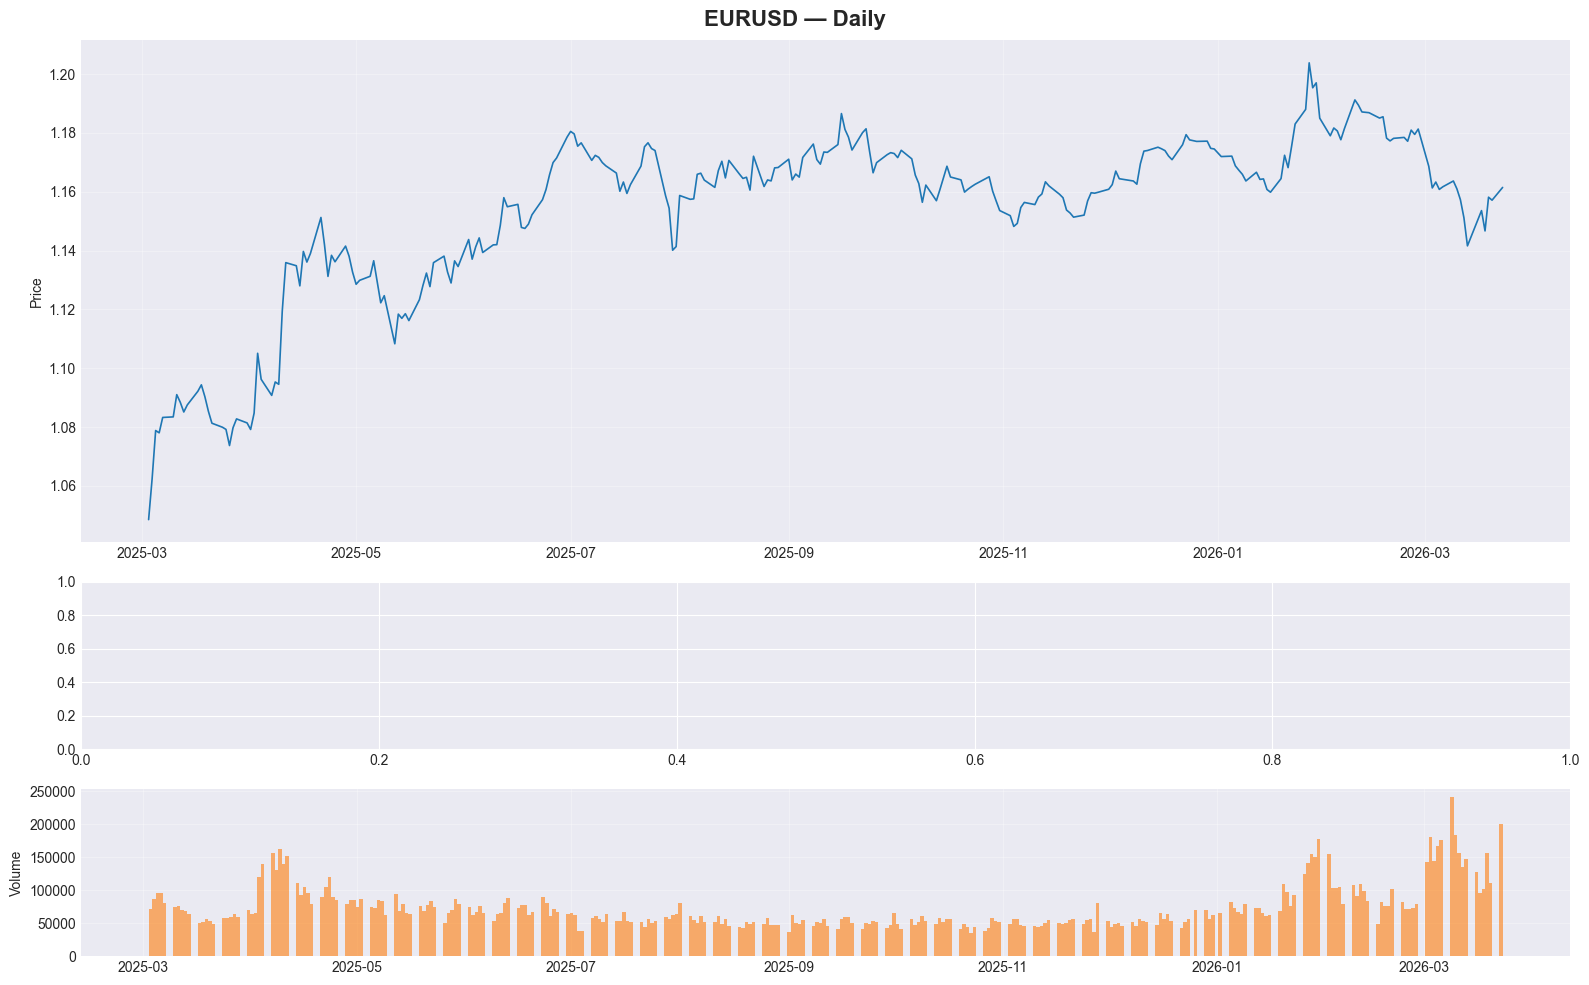

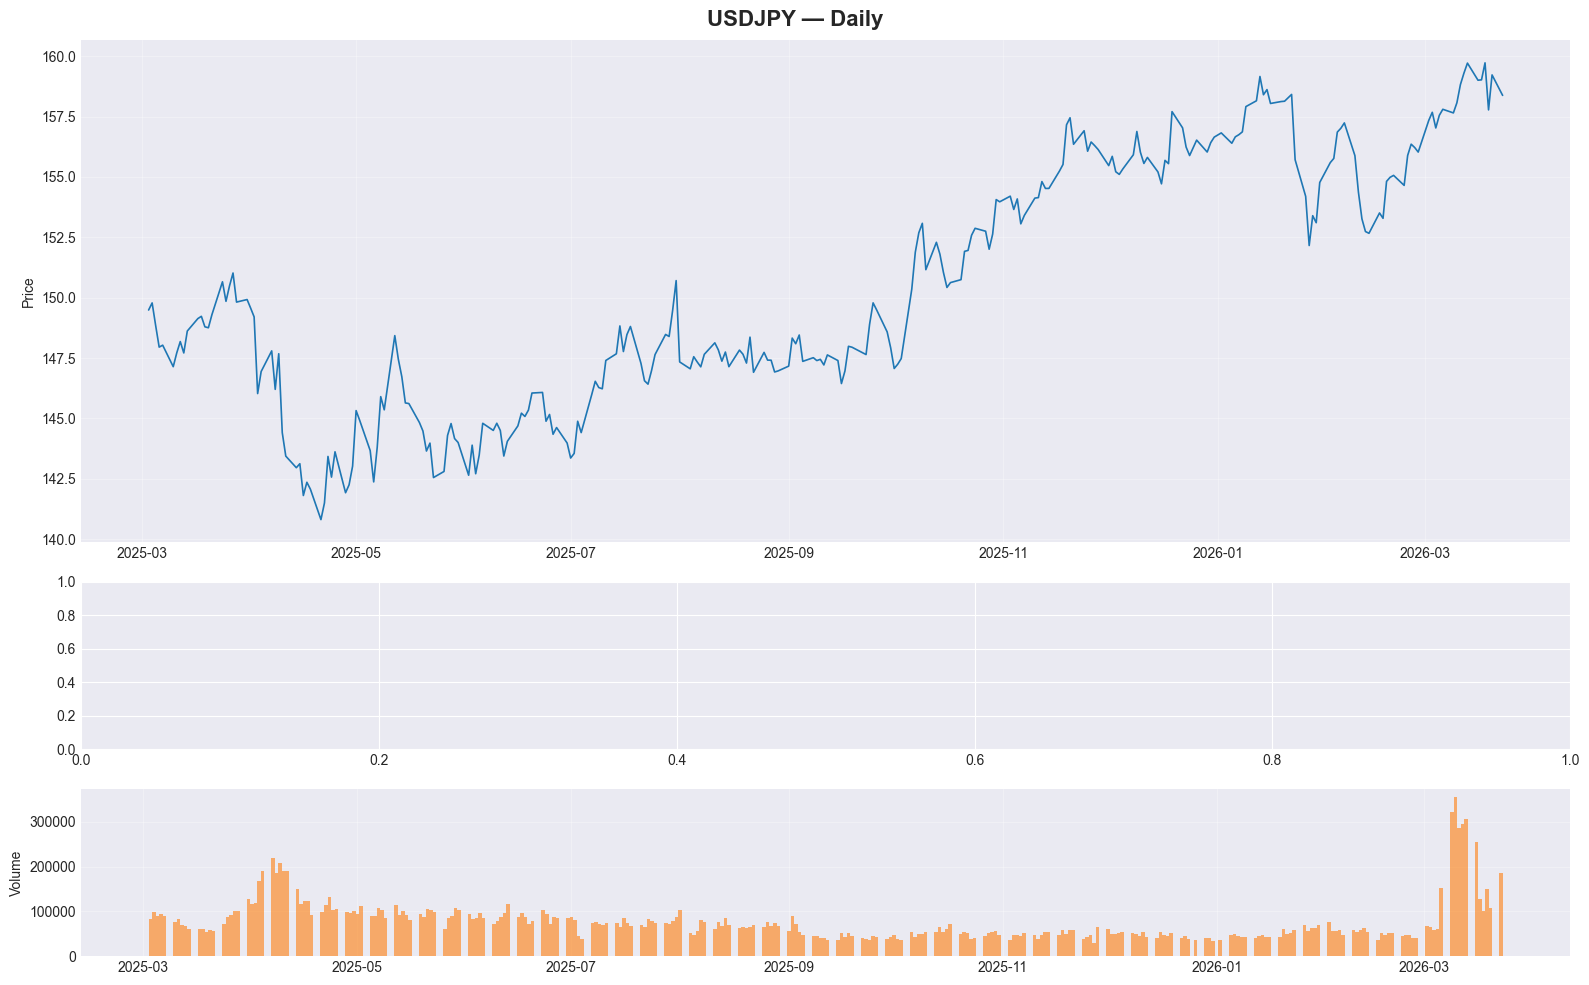

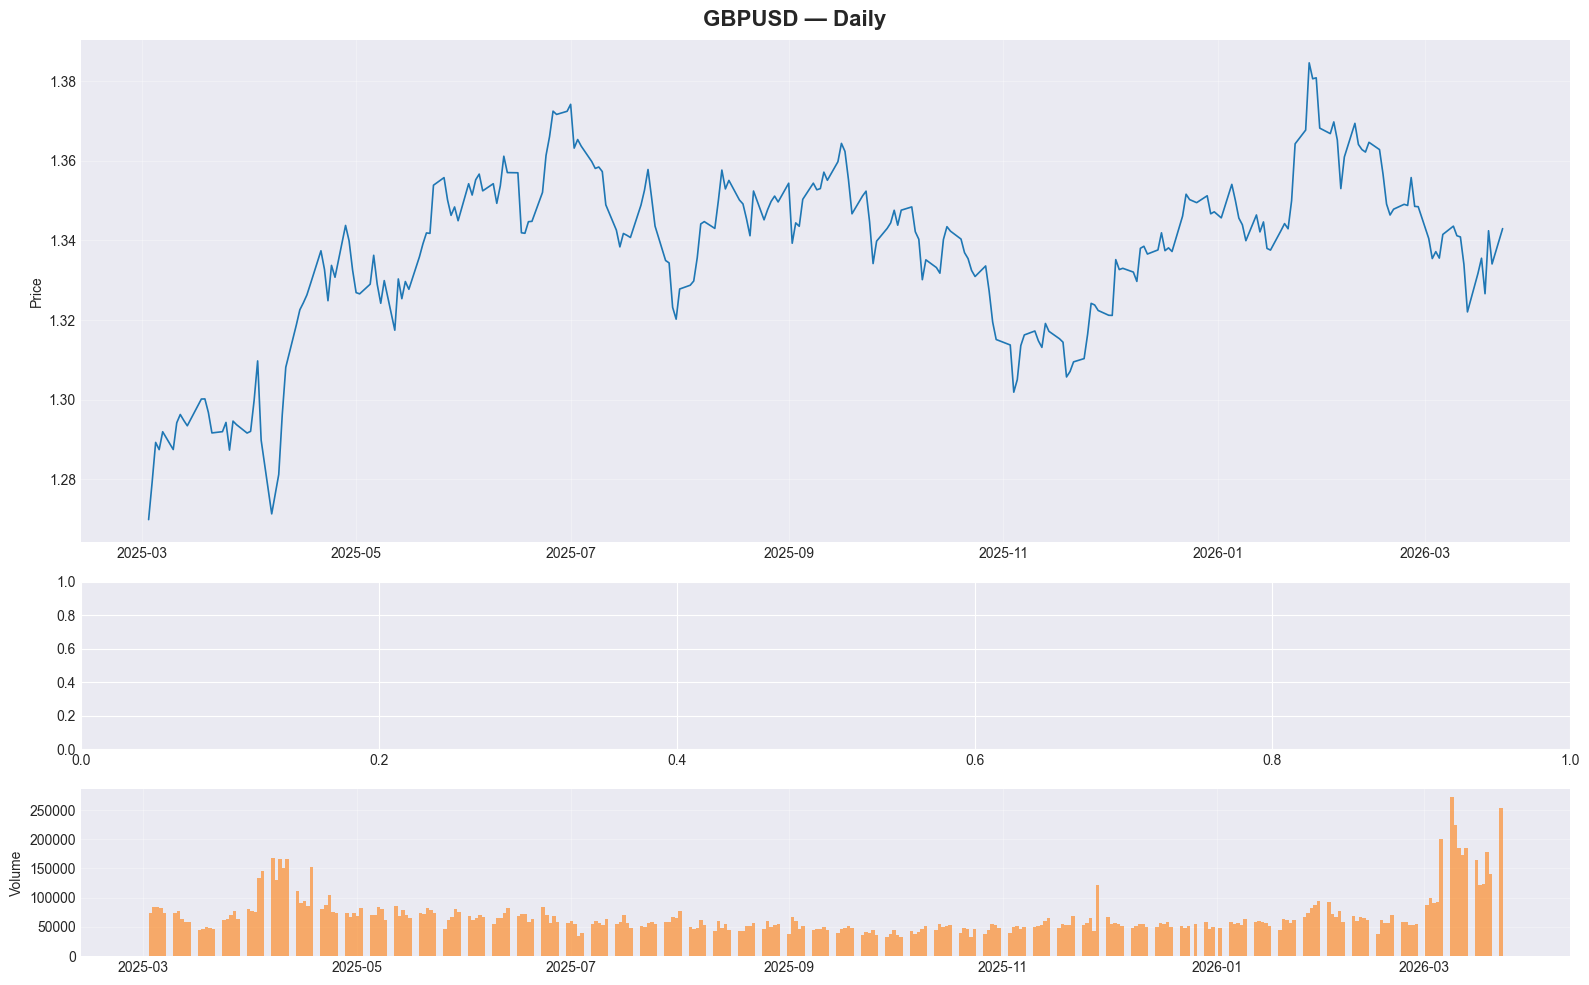

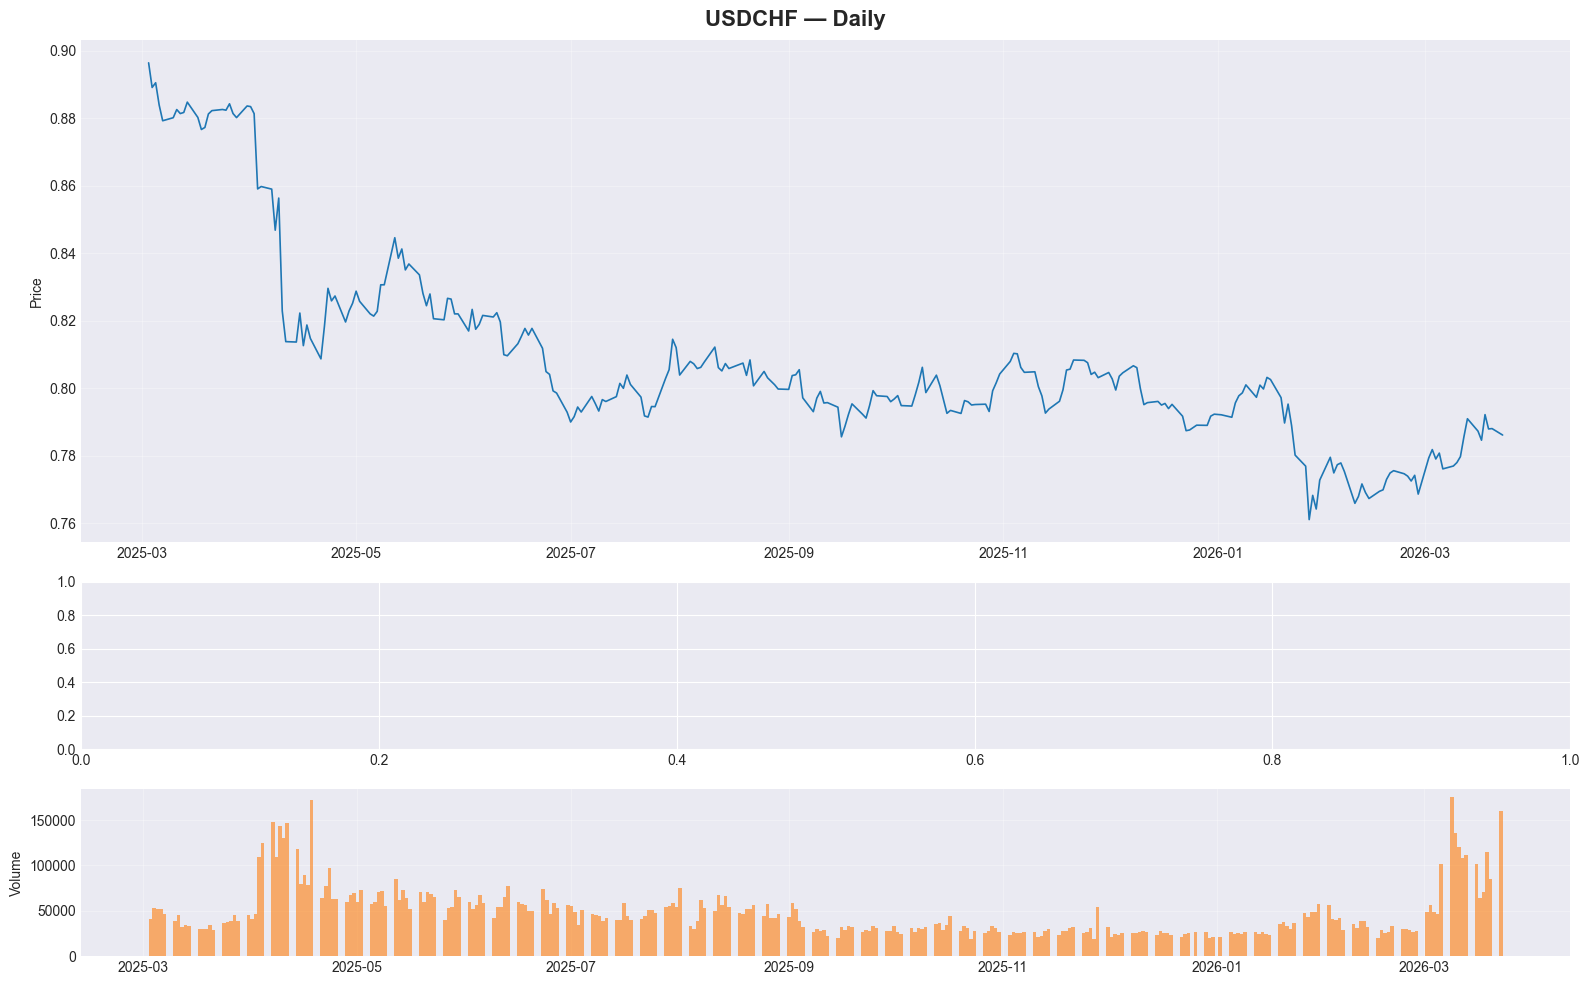

In [3]:
# Price charts for each pair (daily timeframe)
for symbol in PAIRS:
    filepath = INT_DIR / f'integrated_{symbol}_1D.csv'
    if not filepath.exists():
        print(f'⚠️ {filepath.name} not found')
        continue
    df = pd.read_csv(filepath, index_col=0, parse_dates=True)

    fig, axes = plt.subplots(3, 1, figsize=(16, 10), gridspec_kw={'height_ratios': [3, 1, 1]})
    fig.suptitle(f'{symbol} — Daily', fontsize=16, fontweight='bold')

    # Close price
    axes[0].plot(df.index, df['close'], linewidth=1.2, color='#1f77b4')
    if 'sma_50' in df.columns:
        axes[0].plot(df.index, df['sma_50'], linewidth=0.8, color='orange', alpha=0.7, label='SMA 50')
    if 'sma_200' in df.columns:
        axes[0].plot(df.index, df['sma_200'], linewidth=0.8, color='red', alpha=0.7, label='SMA 200')
    axes[0].set_ylabel('Price')
    axes[0].legend(loc='upper left')
    axes[0].grid(True, alpha=0.3)

    # RSI
    if 'rsi_14' in df.columns:
        axes[1].plot(df.index, df['rsi_14'], linewidth=1, color='purple')
        axes[1].axhline(70, color='red', linestyle='--', linewidth=0.7, alpha=0.5)
        axes[1].axhline(30, color='green', linestyle='--', linewidth=0.7, alpha=0.5)
        axes[1].set_ylabel('RSI')
        axes[1].set_ylim(0, 100)
        axes[1].grid(True, alpha=0.3)

    # Volume
    if 'volume' in df.columns:
        axes[2].bar(df.index, df['volume'], width=1, color='#ff7f0e', alpha=0.6)
        axes[2].set_ylabel('Volume')
        axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

---
## 2. FRED Economic Indicators

In [4]:
# FRED EDA Summary
fred_summary = pd.read_csv(EDA_DIR / 'eda_summary_fred.csv')
display(fred_summary)

,Indicator,Records,Mean,Std,Min,Max,Date_Range
0,US 10Y Inflation Expectations,2899,2.021005,0.376099,0.5000,3.0200,2015-01-01 to 2026-02-10
1,US 10Y Treasury,2899,2.659136,1.136863,0.5200,4.9800,2015-01-01 to 2026-02-10
2,USD/CHF Exchange Rate,2897,0.936963,0.056873,0.7666,1.0334,2015-01-01 to 2026-02-06
3,GBP/USD Exchange Rate,2897,1.320756,0.090214,1.0703,1.5882,2015-01-01 to 2026-02-06
4,USD/JPY Exchange Rate,2897,123.122834,17.474236,100.0700,161.7300,2015-01-01 to 2026-02-06
5,US CPI,132,271.592198,29.554858,234.7470,326.0300,2015-01-01 to 2025-12-01
6,US Unemployment Rate,133,4.644697,1.656738,3.4000,14.8000,2015-01-01 to 2026-01-01
7,Federal Funds Rate,133,2.015789,1.917141,0.0500,5.3300,2015-01-01 to 2026-01-01
8,US GDP,43,23263.262326,4123.242490,18063.5290,31098.0270,2015-01-01 to 2025-07-01
9,EUR/USD Exchange Rate,2897,1.120424,0.052029,0.9616,1.2488,2015-01-01 to 2026-02-06


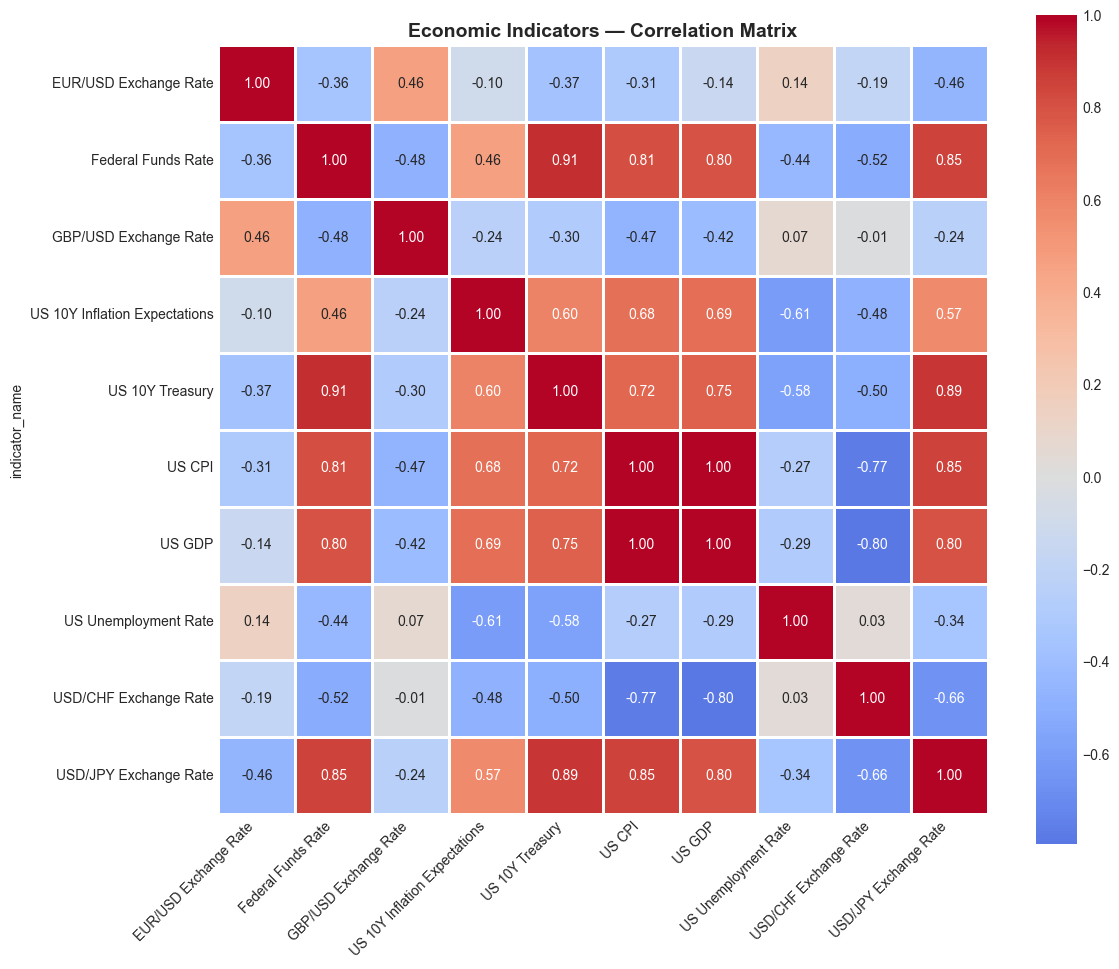

In [5]:
# FRED Correlation Matrix
corr_path = EDA_DIR / 'eda_correlations_fred.csv'
if corr_path.exists():
    corr = pd.read_csv(corr_path, index_col=0)
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                square=True, linewidths=1, ax=ax)
    ax.set_title('Economic Indicators — Correlation Matrix', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('⚠️ Correlation CSV not found')

---
## 3. Feature Engineering Overview

In [6]:
# Feature summary
feat_path = FEAT_DIR / 'features_summary.csv'
if feat_path.exists():
    feat_summary = pd.read_csv(feat_path)
    display(feat_summary)
else:
    print('⚠️ features_summary.csv not found — run feature_engineering.py first')

,Symbol,Timeframe,Candles,Features,Date_Range,NaN_Pct
0,EURUSD,1H,6551,49,2025-03-03 to 2026-03-23,0.174734
1,EURUSD,4H,1642,49,2025-03-03 to 2026-03-23,0.697126
2,EURUSD,1D,274,49,2025-03-03 to 2026-03-23,4.177667
3,USDJPY,1H,6550,49,2025-03-03 to 2026-03-23,0.174760
4,USDJPY,4H,1642,49,2025-03-03 to 2026-03-23,0.697126
5,USDJPY,1D,274,49,2025-03-03 to 2026-03-23,4.177667
6,GBPUSD,1H,6549,49,2025-03-03 to 2026-03-23,0.174787
7,GBPUSD,4H,1642,49,2025-03-03 to 2026-03-23,0.697126
8,GBPUSD,1D,274,49,2025-03-03 to 2026-03-23,4.177667
9,USDCHF,1H,6550,49,2025-03-03 to 2026-03-23,0.174760


In [7]:
# Feature descriptions
desc_path = FEAT_DIR / 'feature_descriptions.csv'
if desc_path.exists():
    display(pd.read_csv(desc_path))
else:
    print('⚠️ feature_descriptions.csv not found')

,Feature,Purpose,Helpfulness
0,returns_simple,Simple return from previous close,Shows price change direction and magnitude.
1,returns_log,Logarithmic return,Better for statistical analysis and compounding.
2,volatility_20,20-period rolling volatility,Measures recent price variability.
3,sma_5,5-period simple moving average,Short-term trend direction.
4,sma_10,10-period simple moving average,Short/medium trend direction.
5,sma_20,20-period simple moving average,Medium-term trend direction.
6,sma_50,50-period simple moving average,Longer-term trend direction.
7,sma_200,200-period simple moving average,Major trend filter.
8,ema_12,12-period exponential moving average,Faster trend signal.
9,ema_26,26-period exponential moving average,Slower trend signal.


---
## 4. Integrated Data & Correlations

In [ ]:
# Integration summary
int_path = INT_DIR / 'integration_summary.csv'
if int_path.exists():
    display(pd.read_csv(int_path))
else:
    print('⚠️ integration_summary.csv not found')

In [ ]:
# Correlation heatmap for EURUSD 1D (top 25 features by abs correlation with close)
eu_path = INT_DIR / 'integrated_EURUSD_1D.csv'
if eu_path.exists():
    df = pd.read_csv(eu_path, index_col=0, parse_dates=True)
    numeric = df.select_dtypes(include=[np.number])
    numeric = numeric.dropna(axis=1, thresh=len(numeric) * 0.5)
    corr = numeric.corr()

    if 'close' in corr.columns:
        top = corr['close'].abs().sort_values(ascending=False).head(26).index
        fig, ax = plt.subplots(figsize=(14, 12))
        sns.heatmap(corr.loc[top, top], annot=False, cmap='coolwarm', center=0,
                    square=True, linewidths=0.5, ax=ax)
        ax.set_title('EURUSD 1D — Top 25 Feature Correlations', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
else:
    print('⚠️ integrated_EURUSD_1D.csv not found')

---
## 5. Data Quality Summary

In [ ]:
# Quality scores
for name in ['data_quality_mt5.csv', 'data_quality_fred.csv', 'data_quality_news.csv']:
    path = EDA_DIR / name
    if path.exists():
        print(f'\n📊 {name}')
        display(pd.read_csv(path))
    else:
        print(f'⚠️ {name} not found')